In [13]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import cmocean.cm as cmo

from pathlib import Path

import src.analysis.plots as plots

DESI_ROOT_DR2 = Path('/global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v2/nonKP')
PAPER_FIGURES_ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/paper/figures/')
if not PAPER_FIGURES_ROOT.exists():
    PAPER_FIGURES_ROOT.mkdir(parents=True)
moc_list = sorted([
    Path(
        '/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/mocs/', 
        f'hsc_moc{i+1}.fits'
    )
    for i in range(0, 4)
])
cmap_hsc = plt.get_cmap('plasma')
cmap_desi = plt.get_cmap('viridis')

# plot infrastructure
pm = plots.PlotManager(root=PAPER_FIGURES_ROOT, overwrite=True)

In [38]:
scale_cut = [1, 5]
expects1 = np.load(f'../statistics/results/expectations_{scale_cut[0]}_{scale_cut[1]}_v2.npz')
scale_cut = [.3, 3]
expects2 = np.load(f'../statistics/results/expectations_{scale_cut[0]}_{scale_cut[1]}_v2.npz')

centers = [0.452, 0.766, 1.081, 1.330]
centers_err = [0.024, 0.022, 0.031, 0.034]

In [ ]:
names = ['npz_cross', 'npz_bs', 'npz_bs_bp', 'npz_bs_bp_mag'] #'npz_cross', 
name_to_label = {
    'npz_cross': 'No bias evolution',
    'npz_bs': r'$b_s(z)$',
    'npz_bs_bp': r'$b_s(z), b_p(z)$',
    'npz_bs_bp_mag': r'$b_s(z), b_p(z), \mu$'
}

In [74]:
data = {
    "Y3 Power Spectrum (Dalal+2023)":                      [None, None, (-0.075, (0.059, 0.056)), (-0.157, (0.111, 0.094))],
    "Y3 Real Space (Li+2023)":                             [None, None, (-0.115, (0.058, 0.052)), (-0.192, (0.088, 0.088))],
    "Y3 CSR (Rana+2025)":                                  [None, (+0.002, (0.022, 0.021)), (-0.002, (0.217, 0.085)), (-0.292, (0.324, 0.229))],
    "Y3 PhotZ (Rau+2022)":                                 [(-0.011, (0.005, 0.005)), (0, (0.004, 0.004)), (-0.003, (0.004, 0.004)), (0, (0.003, 0.003))],
    "Y3 PhotZ & WX (Rau+2022)":                            [(0, (0.004, 0.004)), (0, (0.003, 0.003)), (0, (0.004, 0.004)), None],
    "Y3 Total (Rau+2022)":                                 [(0, (0.024, 0.024)), (0, (0.022, 0.022)), (0, (0.031, 0.031)), (0, (0.034, 0.034))],
}
def format_expect(tomo, name, expects):
    p16, p50, p84 = expects[f'{tomo}/{name}']
    center = centers[tomo-1]

    shift = center - p50
    err_low = p50 - p16 
    err_high = p84 - p50 

    return (shift, (err_low, err_high))

data.update({
    f"1{name_to_label[name]}": [format_expect(tomo, name, expects1) for tomo in range(1, 5)]
    for name in names
})
data.update({
    f"2{name_to_label[name]}": [format_expect(tomo, name, expects2) for tomo in range(1, 5)]
    for name in names
})
print(data)

{'Y3 Power Spectrum (Dalal+2023)': [None, None, (-0.075, (0.059, 0.056)), (-0.157, (0.111, 0.094))], 'Y3 Real Space (Li+2023)': [None, None, (-0.115, (0.058, 0.052)), (-0.192, (0.088, 0.088))], 'Y3 CSR (Rana+2025)': [None, (0.002, (0.022, 0.021)), (-0.002, (0.217, 0.085)), (-0.292, (0.324, 0.229))], 'Y3 PhotZ (Rau+2022)': [(-0.011, (0.005, 0.005)), (0, (0.004, 0.004)), (-0.003, (0.004, 0.004)), (0, (0.003, 0.003))], 'Y3 PhotZ & WX (Rau+2022)': [(0, (0.004, 0.004)), (0, (0.003, 0.003)), (0, (0.004, 0.004)), None], 'Y3 Total (Rau+2022)': [(0, (0.024, 0.024)), (0, (0.022, 0.022)), (0, (0.031, 0.031)), (0, (0.034, 0.034))], '1No bias evolution': [(np.float64(-0.00046963754016399184), (np.float64(0.011672711870384045), np.float64(0.010958337542019636))), (np.float64(0.022231953957764672), (np.float64(0.009234899319375933), np.float64(0.009801746318686688))), (np.float64(-0.06832475735046994), (np.float64(0.03242616246882002), np.float64(0.03340867019236371))), (np.float64(-0.083012634971992

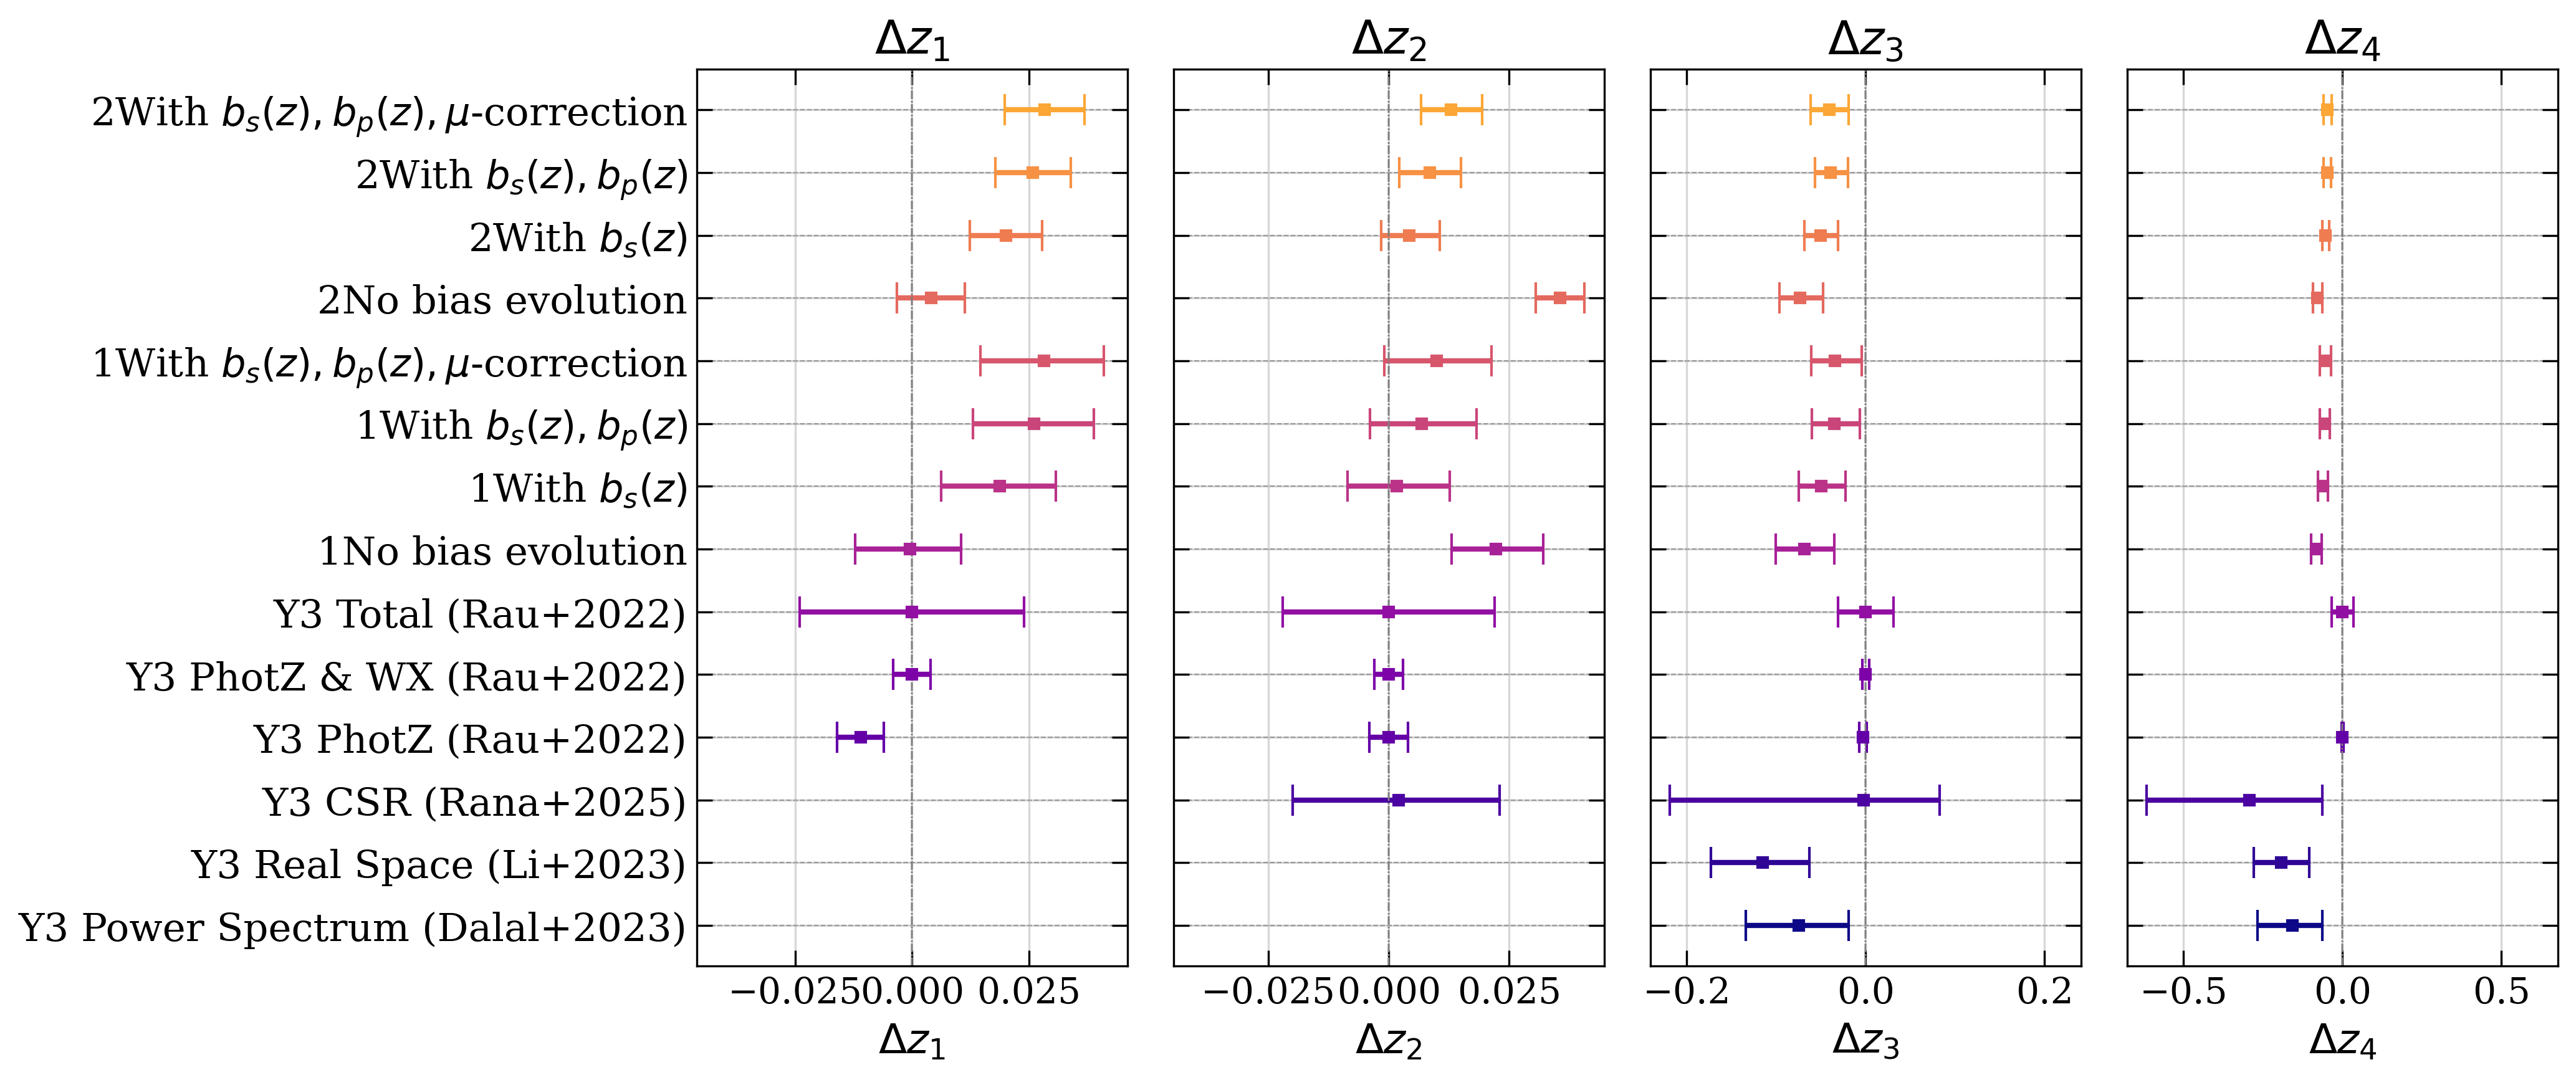

In [41]:
shifts_dz = [r"$\Delta z_1$", r"$\Delta z_2$", r"$\Delta z_3$", r"$\Delta z_4$"]
n_shifts_dz = len(shifts_dz)
labels = list(data.keys())
n_labels = len(labels)

y_pos = np.linspace(0, 1, n_labels)
colors = plt.get_cmap('plasma')(np.linspace(0, 0.8, n_labels))

with pm.make_plot('shifts', nrows=1, ncols=n_shifts_dz, figsize=(14, 6), show=True, sharey=True) as (fig, axs):

    for i, (ax, const_name) in enumerate(zip(axs, shifts_dz)):
        for j, label in enumerate(labels):
            entry = data[label][i]
            if entry is not None:
                val, (err_low, err_high) = entry
                ax.errorbar(
                    val, 
                    y_pos[j], 
                    xerr=[[err_low], [err_high]], 
                    fmt='s',
                    color=colors[j],
                    capsize=6,
                    linewidth=2,
                    markersize=4,
                    )

        ax.set_title(const_name)
        ax.set_xlabel(const_name)
        ax.set_ylim(-0.05, 1.05)

        for y in y_pos:
            ax.axhline(y, color='gray', linestyle='--', linewidth=0.5, zorder=0)
            ax.axvline(0, color='gray', linestyle='-.', linewidth=0.5)

        values_with_errors = [
            (val, err_low, err_high)
            for label in labels
            if (entry := data[label][i]) is not None
            for val, (err_low, err_high) in [entry]
        ]

        if values_with_errors:
            max_extent = max(abs(val) + max(err_low, err_high) for val, err_low, err_high in values_with_errors)
            ax.set_xlim(-max_extent*1.1, max_extent*1.1)
        else:
            ax.set_xlim(-1, 1)

    for ax in axs[1:]:
        ax.set_yticks([])
    axs[0].set_yticks(y_pos)
    axs[0].set_yticklabels(labels, fontsize=15)

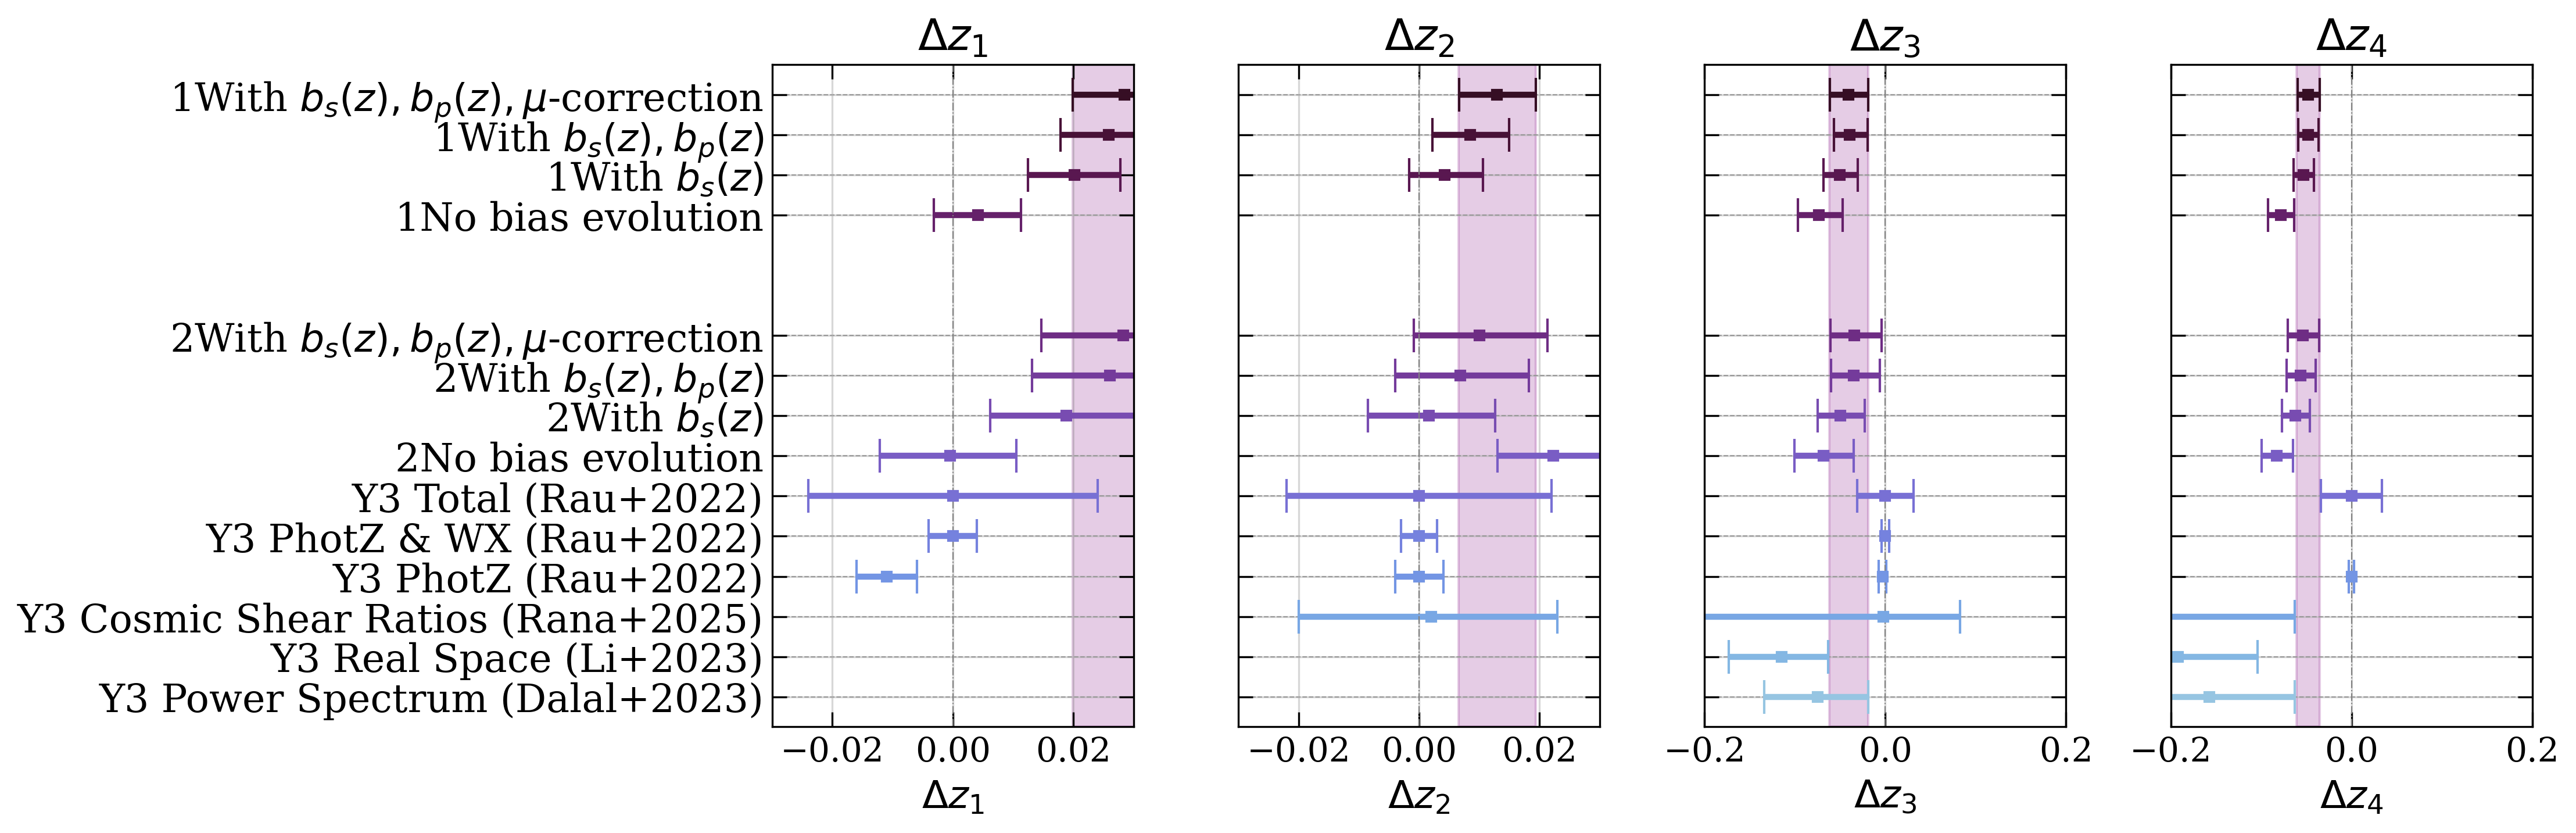

In [ ]:
original_labels = [k for k in data.keys() if not k.startswith("1")]
new_labels = [k for k in data.keys() if k.startswith("1")]

spacing = 2  # number of empty rows between groups
labels = original_labels + [""] * spacing + new_labels

n_labels = len(labels)
y_pos = np.linspace(0, 1, n_labels)
colors = plt.get_cmap('plasma')(np.linspace(0.08, 1, len(original_labels) + len(new_labels)))  # consistent coloring

with pm.make_plot('shifts', nrows=1, ncols=n_shifts_dz, figsize=(15, 5), show=True, sharey=True) as (fig, axs):

    for i, (ax, const_name) in enumerate(zip(axs, shifts_dz)):
        for j, label in enumerate(labels):
            if label == "":
                continue  # skip spacer row
            entry = data[label][i]
            if entry is not None:
                col = colors[j if j < len(original_labels) else j - spacing]
                val, (err_low, err_high) = entry
                ax.errorbar(
                    val, 
                    y_pos[j], 
                    xerr=[[err_low], [err_high]], 
                    fmt='s',
                    color=col,
                    capsize=7,
                    linewidth=2.5,
                    markersize=4,
                )

        ax.set_title(const_name)
        ax.set_xlabel(const_name, fontsize=16)
        ax.set_ylim(-0.05, 1.05)

        for label, y in zip(labels, y_pos):
            if label != "":
                ax.axhline(y, color='gray', linestyle='--', linewidth=0.5, zorder=0)

        ax.axvline(0, color='gray', linestyle='-.', linewidth=0.8, zorder=0)

        values_with_errors = [
            (val, err_low, err_high)
            for label in labels
            if label != "" and (entry := data[label][i]) is not None
            for val, (err_low, err_high) in [entry]
        ]

        if values_with_errors:
            max_extent = max(abs(val) + max(err_low, err_high) for val, err_low, err_high in values_with_errors)
            ax.set_xlim(-max_extent * 1.1, max_extent * 1.1)
        else:
            ax.set_xlim(-1, 1)
            
        if i == 0 or i == 1:
            ax.set_xlim(-0.03, 0.03)
        if i == 2 or i == 3:
            ax.set_xlim(-0.3, 0.3)
        # === Add vertical band on last measurement ===
        last_val = None
        last_err_low = None
        last_err_high = None

        for label in reversed(labels):
            if label == "":
                continue
            entry = data[label][i]
            if entry is not None:
                last_val, (last_err_low, last_err_high) = entry
                break

        if last_val is not None:
            band_start = last_val - max(last_err_low, last_err_high)
            band_end = last_val + max(last_err_low, last_err_high)
            ax.axvspan(band_start, band_end, color='purple', alpha=0.2, zorder=-1)

    for ax in axs[1:]:
        ax.set_yticks([])

    # Set yticks only for real labels (i.e., skip spacer)
    ytick_positions = [y for label, y in zip(labels, y_pos) if label != ""]
    ytick_labels = [label for label in labels if label != ""]

    axs[0].set_yticks(ytick_positions)
    axs[0].set_yticklabels(ytick_labels, fontsize=16)


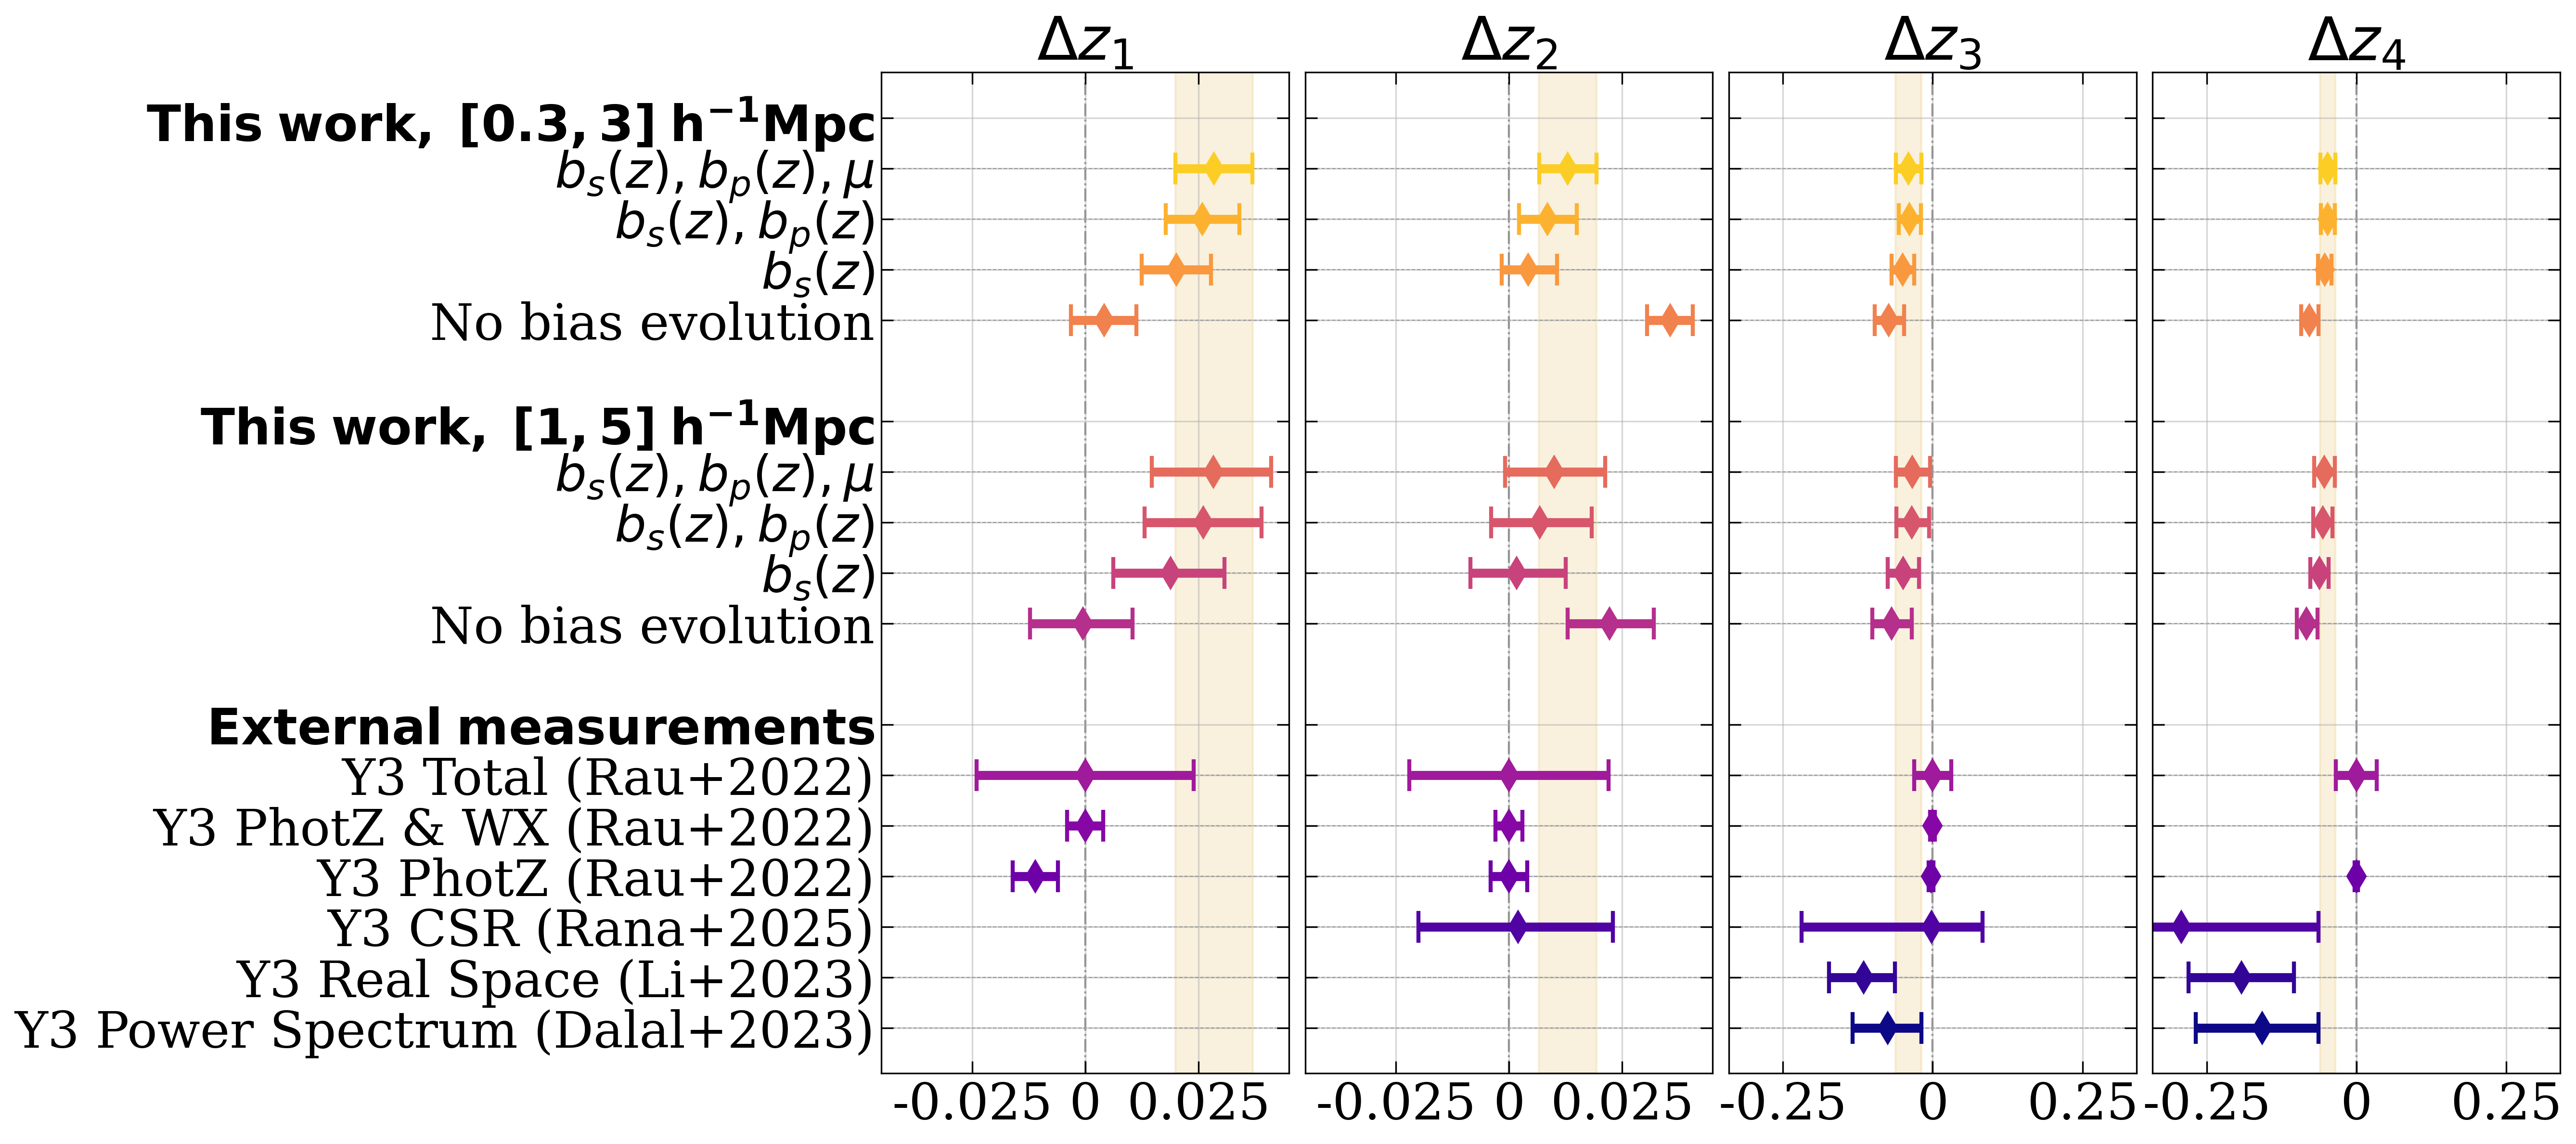

In [ ]:
block_orig = [k for k in data.keys() if not (k.startswith("1") or k.startswith("2"))]
block1 = [k for k in data.keys() if k.startswith("1")]
block2 = [k for k in data.keys() if k.startswith("2")]

spacing = 1

labels = (
    block_orig + ["External\; measurements Section"] + [""] * spacing
    + block1 + ["This\; work,\;"+r"[1, 5]\; h^{-1}Mpc"+ "Section"] + [""] * spacing
    + block2 + ["This\; work,\;"+r"[0.3, 3]\; h^{-1}Mpc" + "Section"]
)

n_labels = len(labels)
y_pos = np.linspace(0, 1, n_labels)

real_labels = block_orig + block1 + block2
colors = plt.get_cmap('plasma')(np.linspace(0, 0.9, len(real_labels)))

with pm.make_plot('shifts', nrows=1, ncols=n_shifts_dz, figsize=(15, 9), show=True, sharey=True, tight_layout=False) as (fig, axs):

    fig.subplots_adjust(wspace=0.04)

    for i, (ax, const_name) in enumerate(zip(axs, shifts_dz)):
        for j, label in enumerate(labels):
            if label == "" or "Section" in label:
                continue

            entry = data[label][i]
            if entry is not None:
                col = colors[real_labels.index(label)]
                val, (err_low, err_high) = entry
                ax.errorbar(
                    val,
                    y_pos[j],
                    xerr=[[err_low], [err_high]],
                    fmt='d',
                    color=col,
                    capthick=2,
                    capsize=8,
                    linewidth=4.5,
                    markersize=11,
                )

        ax.set_title(const_name, fontsize=30)
        ax.set_ylim(-0.05, 1.05)

        for label, y in zip(labels, y_pos):
            if label != "" and "Section" not in label:
                ax.axhline(y, color='gray', linestyle='--', linewidth=0.5, zorder=0)

        ax.axvline(0, color='gray', linestyle='-.', linewidth=1, zorder=0)

        values_with_errors = [
            (val, err_low, err_high)
            for label in labels
            if label != "" and "Section" not in label and (entry := data[label][i]) is not None
            for val, (err_low, err_high) in [entry]
        ]

        if i == 0 or i == 1:
            ax.set_xlim(-0.045, 0.045)
        if i == 2 or i == 3:
            ax.set_xlim(-0.34, 0.34)

        last_val = None
        last_err_low = None
        last_err_high = None

        for label in reversed(labels):
            if label == "" or "Section" in label:
                continue
            entry = data[label][i]
            if entry is not None:
                last_val, (last_err_low, last_err_high) = entry
                break

        if last_val is not None:
            band_start = last_val - max(last_err_low, last_err_high)
            band_end = last_val + max(last_err_low, last_err_high)
            ax.axvspan(band_start, band_end, color='goldenrod', alpha=0.15, zorder=-1)

        from matplotlib.ticker import FuncFormatter
        
        def xfmt(x, pos):
            s = f"{x:.3f}".rstrip("0").rstrip(".")
            return s
        ax.xaxis.set_major_formatter(FuncFormatter(xfmt))
        ax.tick_params(axis='x', labelsize=22)

    ytick_positions = [y for label, y in zip(labels, y_pos) if label != ""]
    ytick_labels = []
    for label in labels:
        if label == "":
            continue
        if "Section" in label:
            # remove "Section"
            label = label.replace("Section", "").strip()
            # section header in bold
            ytick_labels.append(r"$\bf{" + label + "}$")
        else:
            # remove leading "1" or "2" from labels
            if label[0] in ("1", "2"):
                ytick_labels.append(label[1:].strip())
            else:
                ytick_labels.append(label)

    axs[0].set_yticks(ytick_positions)
    axs[0].set_yticklabels(ytick_labels, fontsize=25)


Scale .3 3
------------

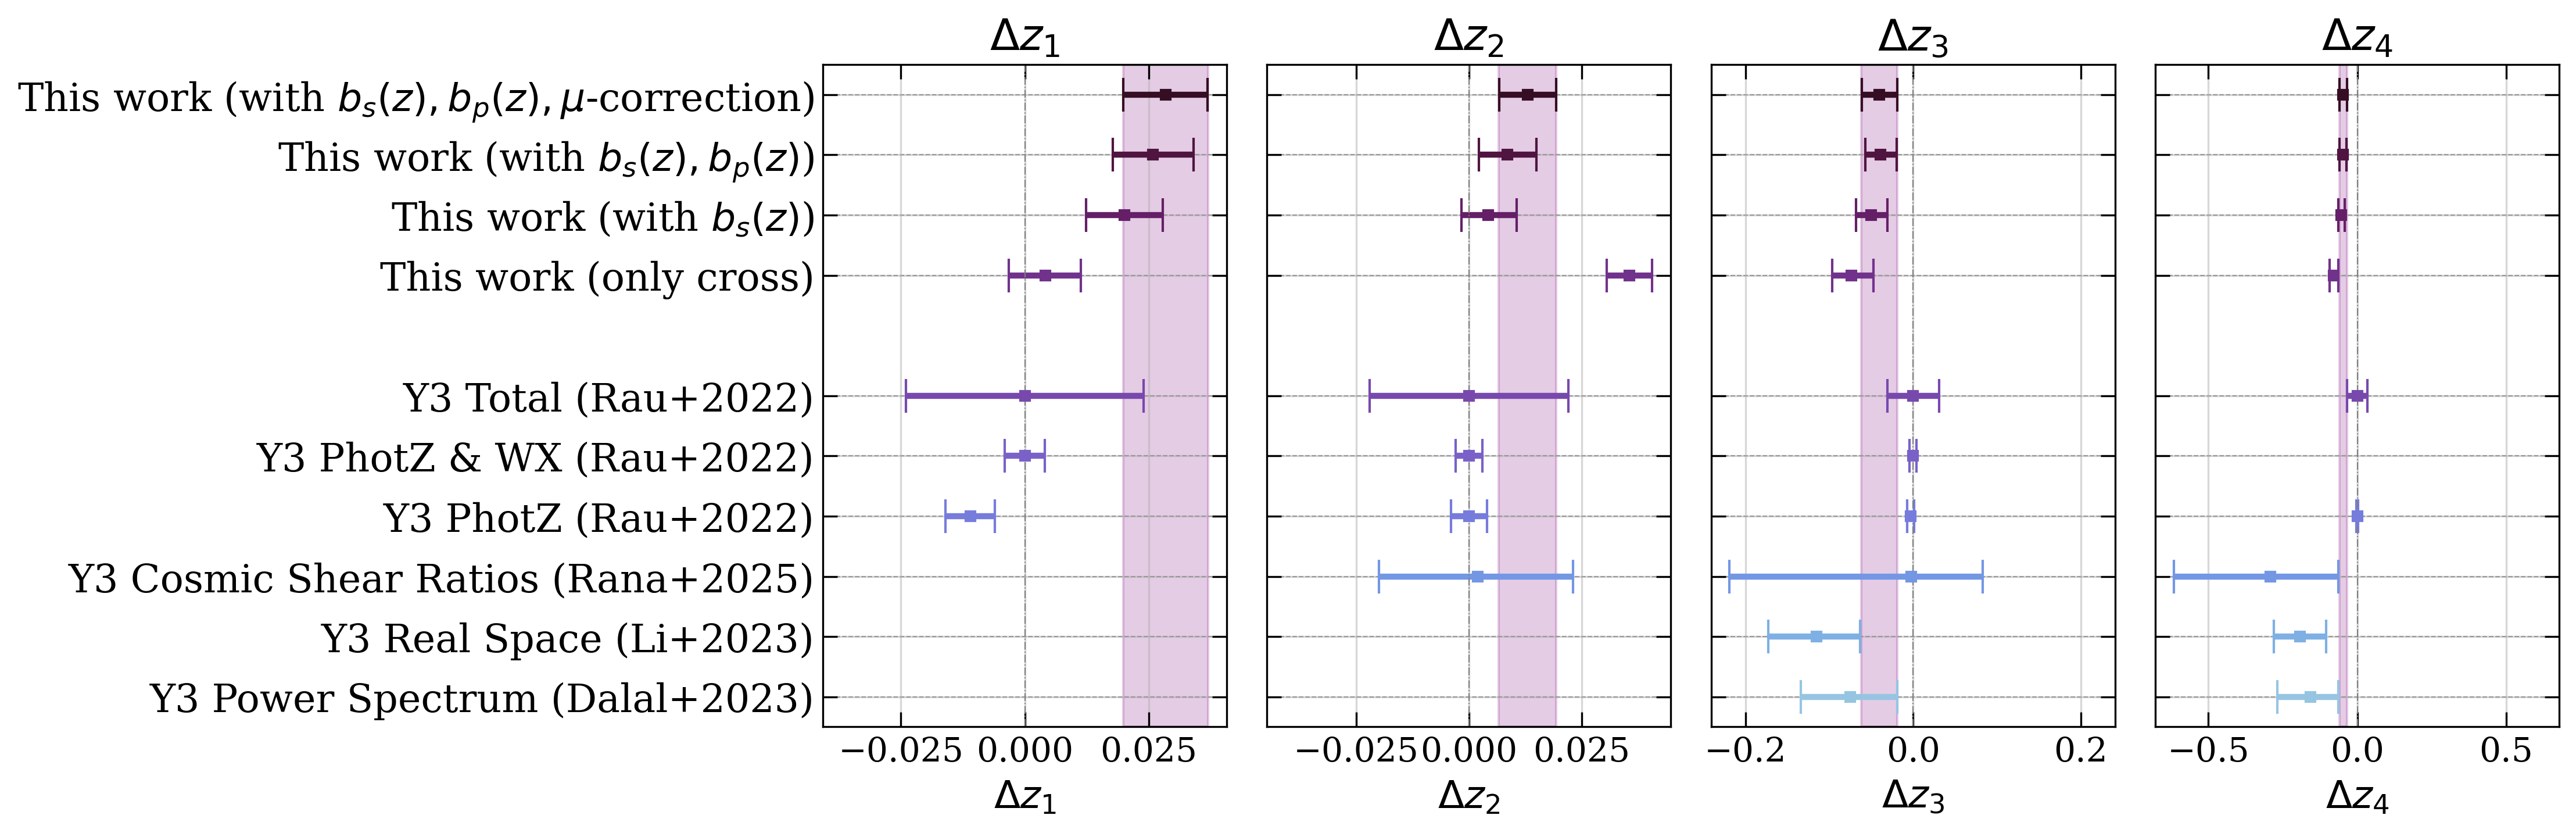

Scale 1. 5
------------

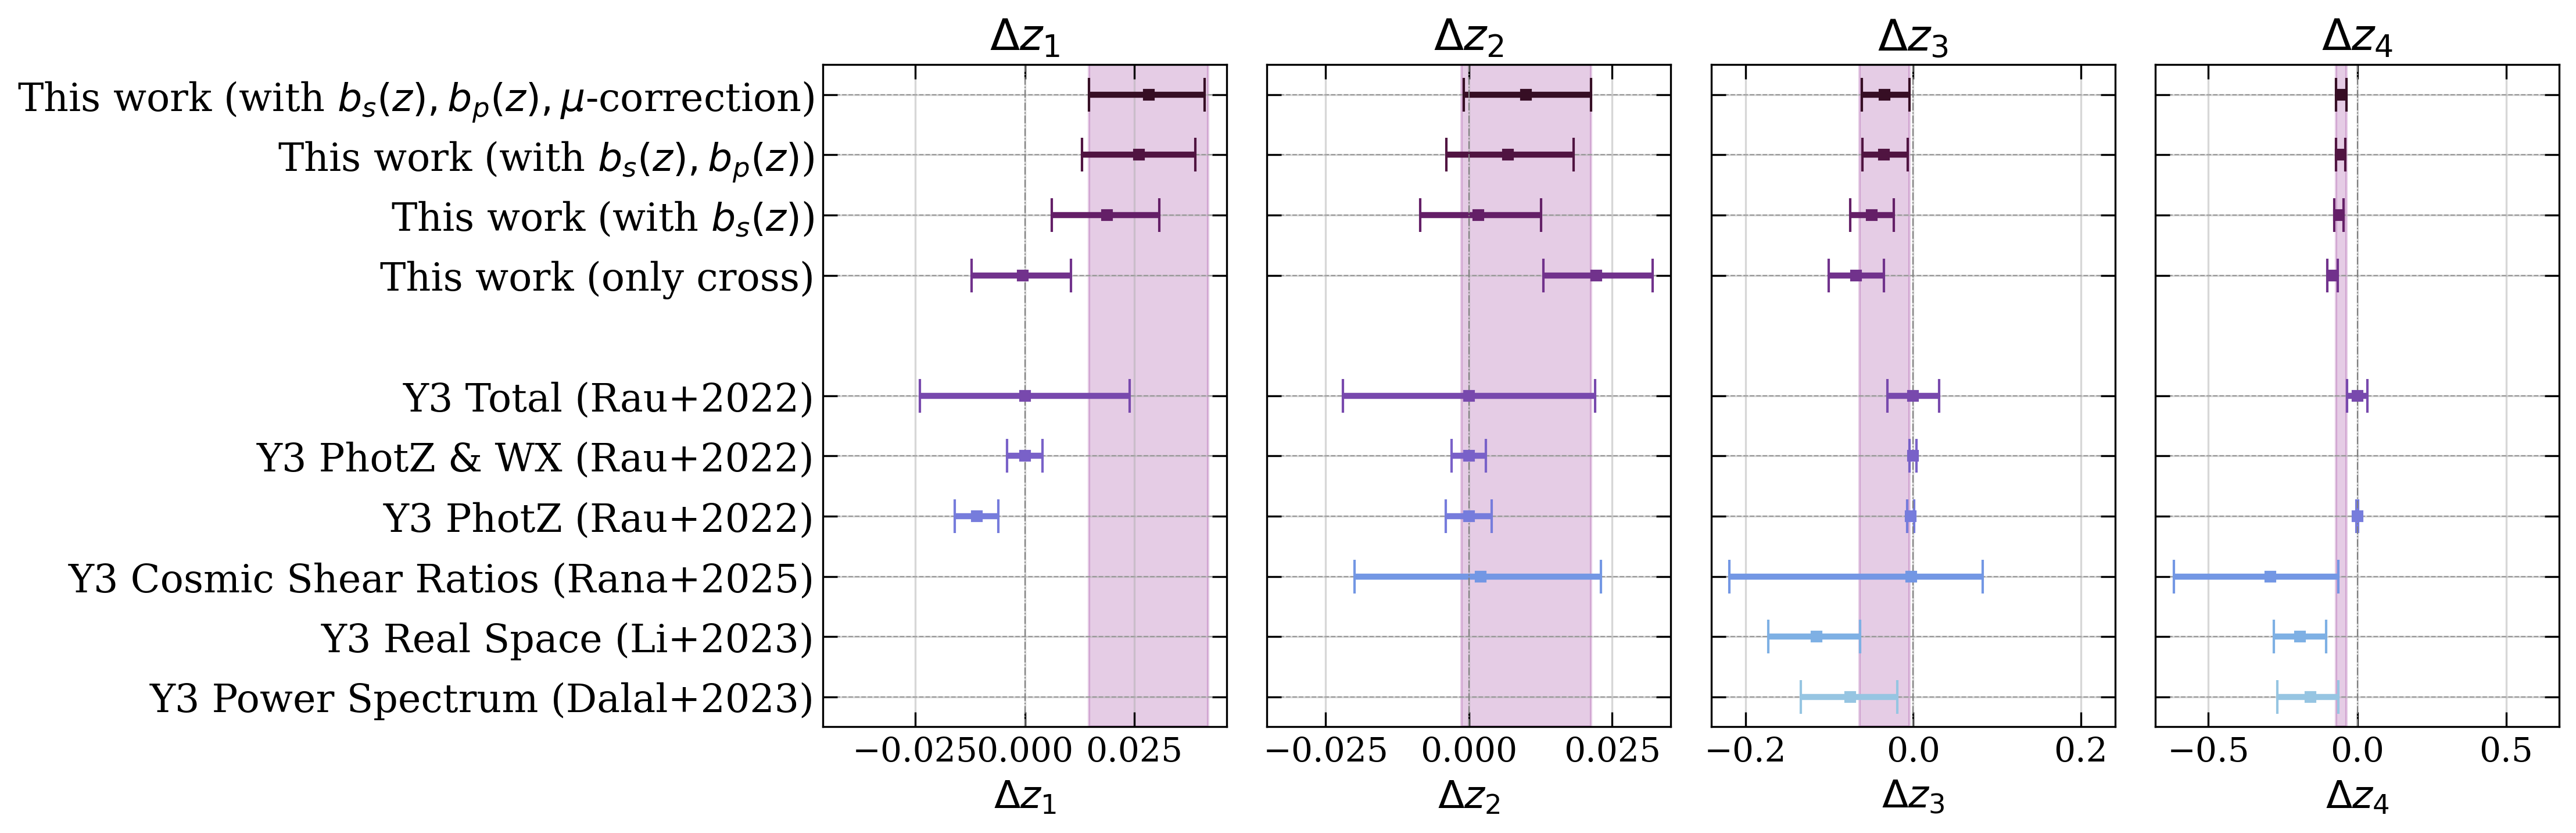

Photometric galaxy bias mitigation
----------------------------------

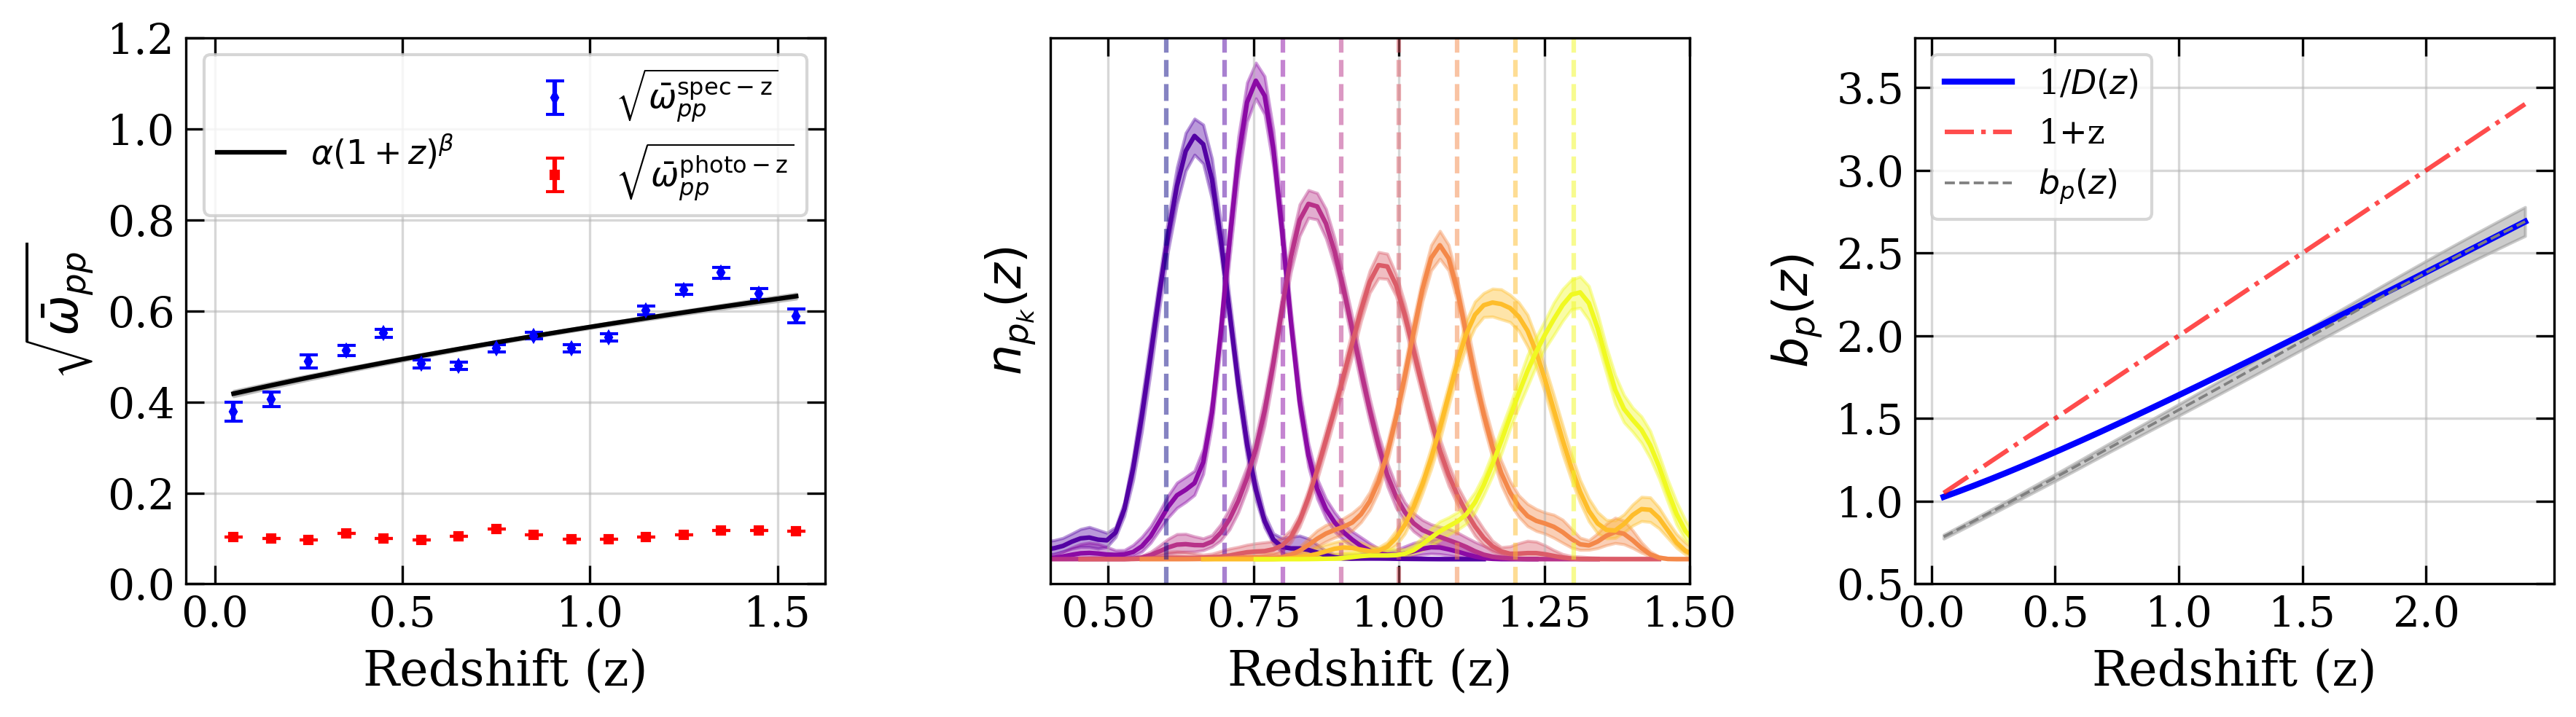